# Operational Diagnostics Report — Oil & Gas Pod
### The Nairobi Bottleneck Investigation

**Author:** _David Kimathi Muthui_
**Pod:** Oil & Gas
**Dataset:** `Mystery_Ops.csv` — daily depot-shift operational records for 2026 across four depots (Nairobi, Mombasa, Kisumu, Eldoret)
**Primary KPI:** `throughput_barrels`

**Objective:** One of our four depots is underperforming. This notebook profiles the data, detects anomalies, drills down to isolate the root cause, quantifies its impact with Pareto analysis, and rules out confounding drivers (e.g. temperature) with correlation analysis — before recommending a fix.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = "flare"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading & Cleaning

`operation_date` is stored as `DD/MM/YYYY` text, so it needs explicit parsing (`dayfirst=True`) rather than pandas' default inference — left alone, pandas would silently swap day/month for any day ≤ 12 and corrupt the time series.


In [2]:
df = pd.read_csv("Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")

# Categorical typing for cleaner grouping/memory
for c in ["depot", "shift", "machine_id", "incident_type"]:
    df[c] = df[c].astype("category")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['operation_date'].min().date()} to {df['operation_date'].max().date()}")
df.head()


Shape: 2920 rows x 11 columns
Date range: 2026-01-01 to 2026-12-31


,record_id,operation_date,depot,shift,operator_id,machine_id,throughput_barrels,temperature_c,maintenance_flag,voltage_count,incident_type
0,MO-20260224-MOM-D,2026-02-24,Mombasa,Day,OP-M02,MBA-P01,1069.7,34.6,0,230,none
1,MO-20261015-KIS-D,2026-10-15,Kisumu,Day,OP-K01,KSM-P01,1051.6,25.5,0,227,none
2,MO-20260518-MOM-D,2026-05-18,Mombasa,Day,OP-M04,MBA-P01,999.3,37.1,0,209,none
3,MO-20260209-MOM-N,2026-02-09,Mombasa,Night,OP-M04,MBA-P03,1038.7,32.4,0,213,none
4,MO-20260318-MOM-N,2026-03-18,Mombasa,Night,OP-M02,MBA-P01,939.7,34.5,0,225,none


## 2. Data Profiling

### 2.1 Structure & missing values


In [3]:
print(df.dtypes)
print()
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
print("Columns with missing values:")
print(missing_summary)


record_id                     object
operation_date        datetime64[ns]
depot                       category
shift                       category
operator_id                   object
machine_id                  category
throughput_barrels           float64
temperature_c                float64
maintenance_flag               int64
voltage_count                  int64
incident_type               category
dtype: object

Columns with missing values:
                    missing_count  missing_pct
operator_id                    18         0.62
throughput_barrels              5         0.17
temperature_c                  20         0.68


`operator_id` (18 missing), `throughput_barrels` (5 missing, per the data dictionary's "simulated export gap"), and `temperature_c` (20 missing) all have gaps. We'll check next whether the `temperature_c` gaps cluster in one depot, since the data dictionary flags a *"systematic Nairobi sensor outage"* — if so, that's a data-quality issue to control for, not a real signal.

In [4]:
temp_missing_by_depot = df[df["temperature_c"].isna()]["depot"].value_counts()
print("Missing temperature_c readings by depot:")
print(temp_missing_by_depot)


Missing temperature_c readings by depot:
depot
Nairobi    20
Eldoret     0
Kisumu      0
Mombasa     0
Name: count, dtype: int64


### 2.2 Summary statistics (numeric columns)

In [4]:
summary_stats = df[["throughput_barrels", "temperature_c", "voltage_count"]].describe().round(2)
summary_stats


,throughput_barrels,temperature_c,voltage_count
count,2915.00,2900.00,2920.00
mean,916.89,25.05,221.12
std,168.12,5.57,6.52
min,296.50,10.90,197.00
25%,872.85,21.20,217.00
50%,969.30,25.10,221.00
75%,1029.65,29.10,225.00
max,1210.60,39.90,242.00


## 3. Univariate Analysis

Distribution of the KPI and its main candidate drivers, plus the shape of the categorical fields.


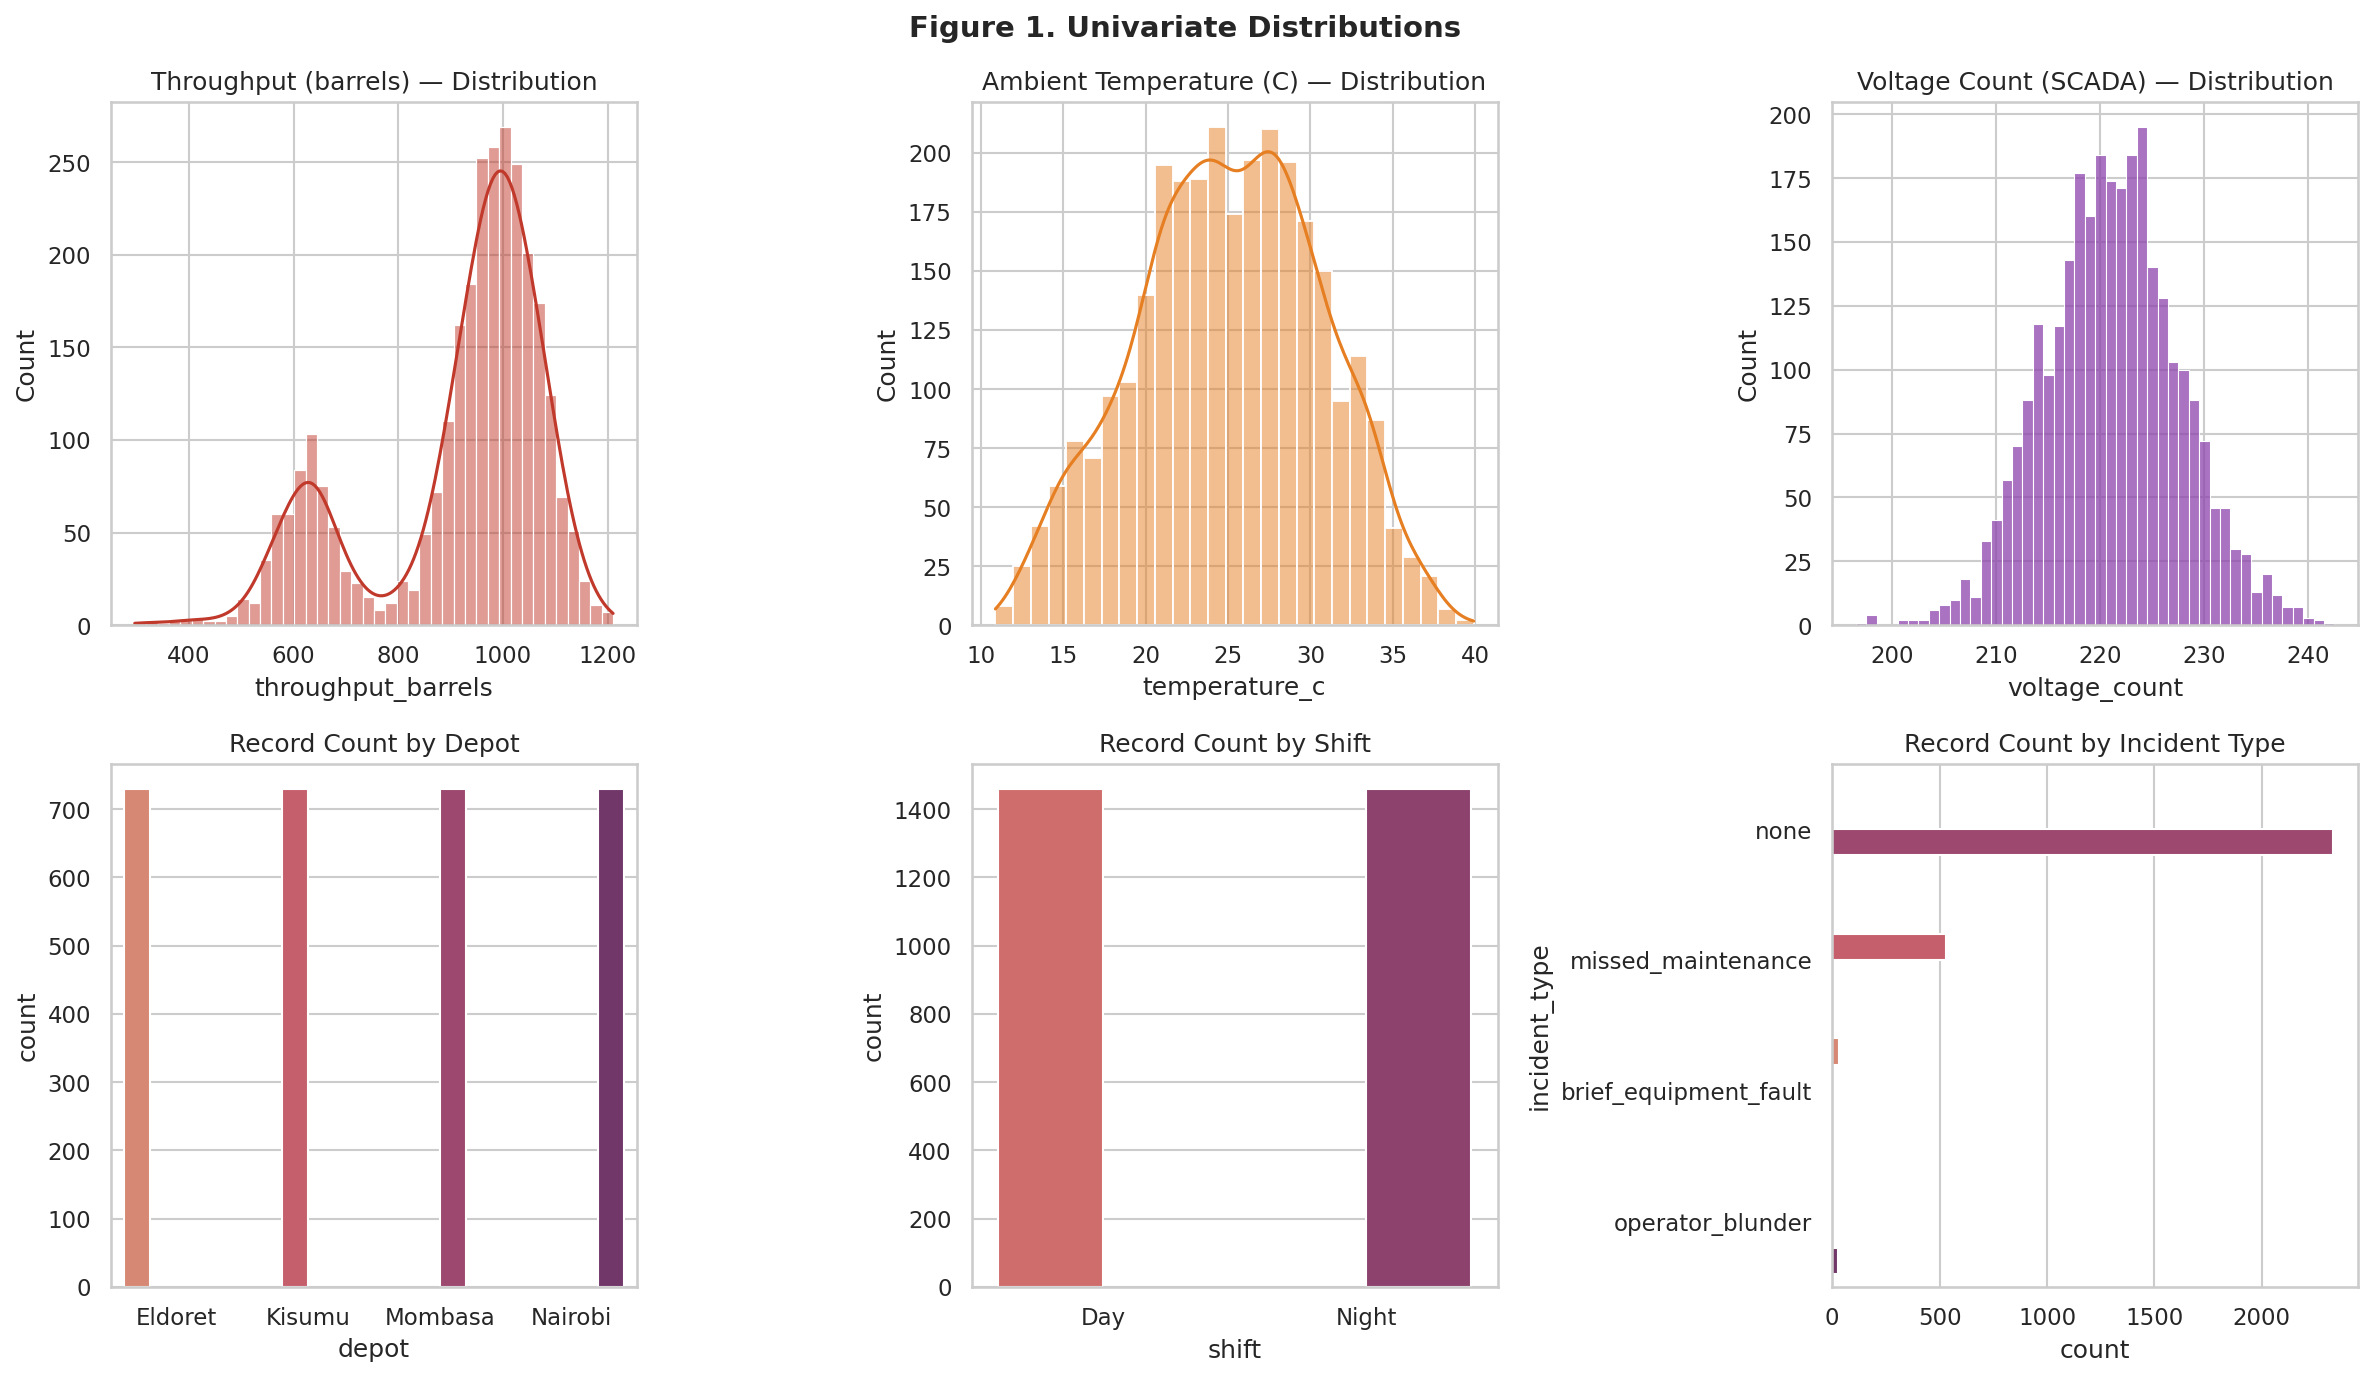

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df["throughput_barrels"].dropna(), kde=True, ax=axes[0,0], color="#c0392b")
axes[0,0].set_title("Throughput (barrels) — Distribution")

sns.histplot(df["temperature_c"].dropna(), kde=True, ax=axes[0,1], color="#e67e22")
axes[0,1].set_title("Ambient Temperature (C) — Distribution")

sns.histplot(df["voltage_count"], kde=False, discrete=True, ax=axes[0,2], color="#8e44ad")
axes[0,2].set_title("Voltage Count (SCADA) — Distribution")

sns.countplot(data=df, x="depot", order=df["depot"].value_counts().index, ax=axes[1,0], palette=PALETTE, hue="depot", legend=False)
axes[1,0].set_title("Record Count by Depot")

sns.countplot(data=df, x="shift", ax=axes[1,1], palette=PALETTE, hue="shift", legend=False)
axes[1,1].set_title("Record Count by Shift")

sns.countplot(data=df, y="incident_type", order=df["incident_type"].value_counts().index, ax=axes[1,2], palette=PALETTE, hue="incident_type", legend=False)
axes[1,2].set_title("Record Count by Incident Type")

plt.tight_layout()
plt.suptitle("Figure 1. Univariate Distributions", y=1.02, fontsize=14, fontweight="bold")
plt.show()


**Reading Figure 1:** `throughput_barrels` is close to a single unimodal distribution but with a visible left-side hump — a hint that more than one population (e.g. "normal operations" vs "a depot in trouble") is mixed together, which we'll confirm in the bivariate step. Records are perfectly balanced across depots and shifts (365 days x 4 depots x 2 shifts), so no sampling bias to worry about there. `incident_type` is dominated by `none`, with `missed_maintenance` as a distant second — already a hint about where the anomaly investigation should focus.

## 4. Bivariate Analysis

Breaking throughput down by the categorical fields is where the story starts to emerge.


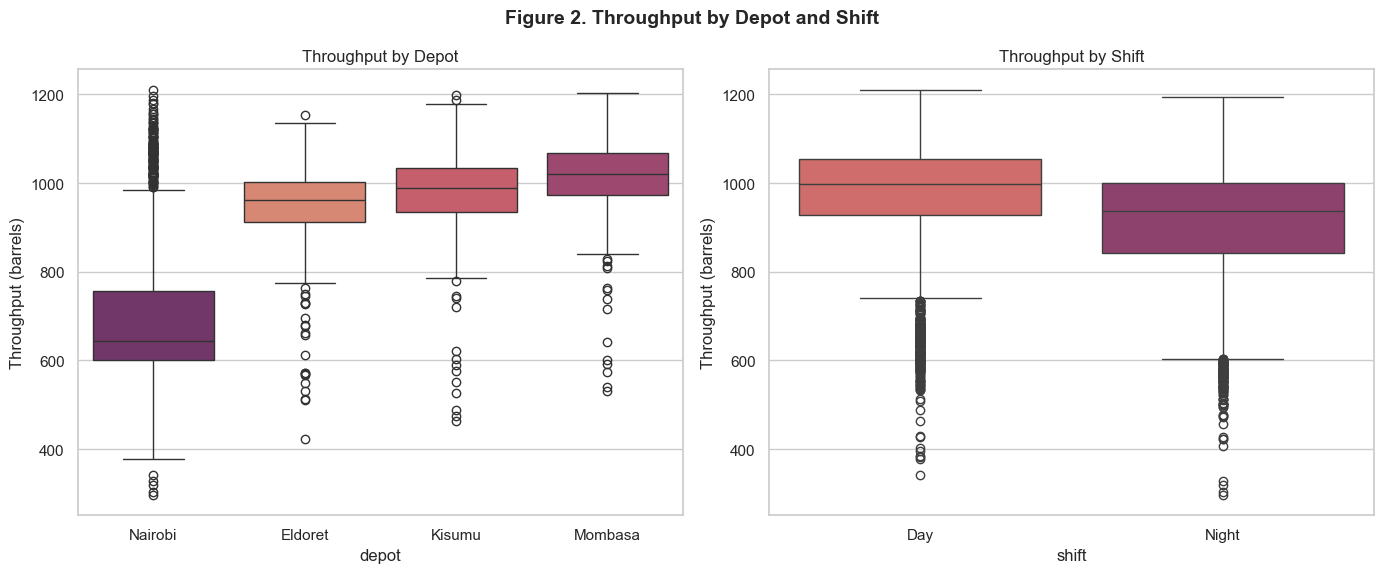

depot
Nairobi     644.5
Eldoret     960.7
Kisumu      988.6
Mombasa    1021.2
Name: throughput_barrels, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

order = df.groupby("depot", observed=True)["throughput_barrels"].median().sort_values().index
sns.boxplot(data=df, x="depot", y="throughput_barrels", order=order, ax=axes[0], palette=PALETTE, hue="depot", legend=False)
axes[0].set_title("Throughput by Depot")
axes[0].set_ylabel("Throughput (barrels)")

sns.boxplot(data=df, x="shift", y="throughput_barrels", ax=axes[1], palette=PALETTE, hue="shift", legend=False)
axes[1].set_title("Throughput by Shift")
axes[1].set_ylabel("Throughput (barrels)")

plt.tight_layout()
plt.suptitle("Figure 2. Throughput by Depot and Shift", y=1.04, fontsize=14, fontweight="bold")
plt.show()

print(df.groupby("depot", observed=True)["throughput_barrels"].median().sort_values().round(1))


**Reading Figure 2:** Nairobi's median throughput and its whole box sit visibly below the other three depots, which otherwise look similar to each other. Shift (Day vs Night) shows no meaningful difference — so shift isn't a driver. Depot is clearly where the problem lives; the next step is to see whether that gap is real (an anomaly to investigate) or just Nairobi's normal baseline.

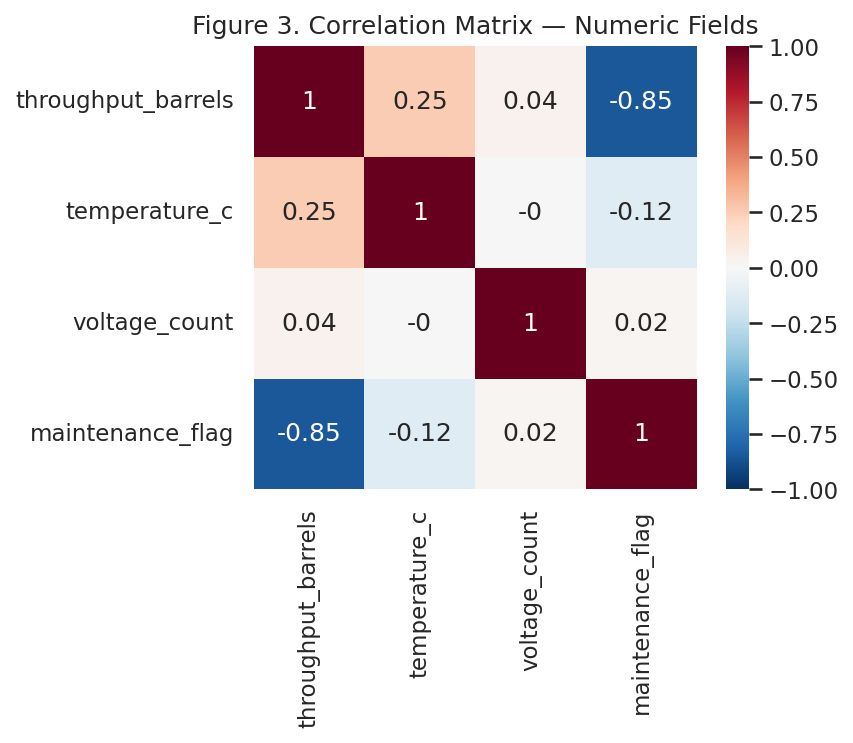

In [8]:
corr_cols = ["throughput_barrels", "temperature_c", "voltage_count", "maintenance_flag"]
corr = df[corr_cols].corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Figure 3. Correlation Matrix — Numeric Fields")
plt.tight_layout()
plt.show()


**Reading Figure 3:** `maintenance_flag` has by far the strongest relationship with throughput (a substantial negative correlation), while `temperature_c` and `voltage_count` are both close to zero. That's an early signal that weather is not the driver — we'll test it properly in Section 7.

## 5. Anomaly Detection

Using the IQR rule (values beyond 1.5x the interquartile range) applied **within each depot**, since a global threshold would just flag "being Nairobi" as an anomaly rather than finding genuine outlier shifts.


In [9]:
def iqr_outliers(group):
    q1, q3 = group["throughput_barrels"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (group["throughput_barrels"] < lower) | (group["throughput_barrels"] > upper)

df["is_outlier"] = df.groupby("depot", observed=True, group_keys=False).apply(iqr_outliers)

outlier_counts = df[df["is_outlier"]].groupby("depot", observed=True).size().sort_values(ascending=False)
print("Outlier shift-records per depot (within-depot IQR method):")
print(outlier_counts)
print()
print("Outlier records by incident_type:")
print(df[df["is_outlier"]]["incident_type"].value_counts())


Outlier shift-records per depot (within-depot IQR method):
depot
Nairobi    143
Eldoret     22
Kisumu      15
Mombasa     14
dtype: int64

Outlier records by incident_type:
incident_type
none                     154
brief_equipment_fault     21
operator_blunder          19
missed_maintenance         0
Name: count, dtype: int64


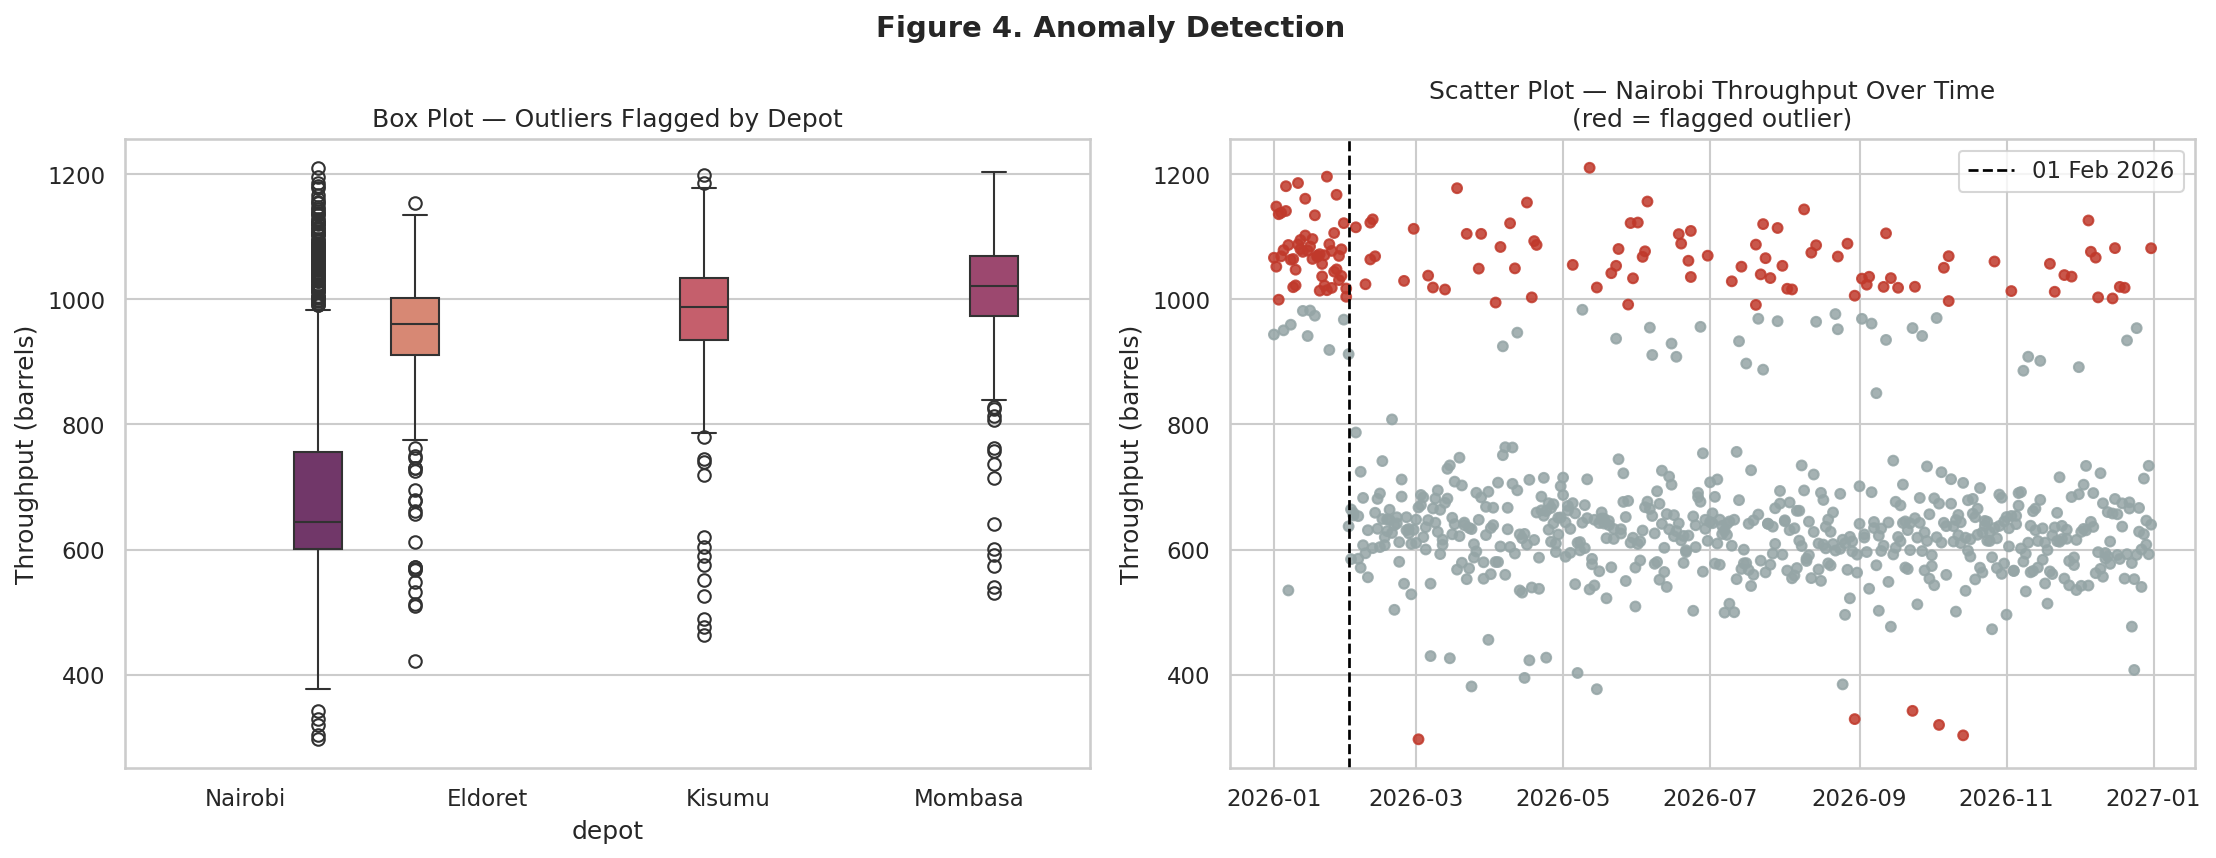

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.boxplot(data=df, x="depot", y="throughput_barrels", order=order, ax=axes[0], palette=PALETTE, hue="depot", legend=False, showfliers=True)
axes[0].set_title("Box Plot — Outliers Flagged by Depot")
axes[0].set_ylabel("Throughput (barrels)")

nai = df[df["depot"] == "Nairobi"].sort_values("operation_date")
axes[1].scatter(nai["operation_date"], nai["throughput_barrels"],
                 c=nai["is_outlier"].map({True: "#c0392b", False: "#95a5a6"}),
                 s=22, alpha=0.85)
axes[1].axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1.3, label="01 Feb 2026")
axes[1].set_title("Scatter Plot — Nairobi Throughput Over Time\n(red = flagged outlier)")
axes[1].set_ylabel("Throughput (barrels)")
axes[1].legend()

plt.tight_layout()
plt.suptitle("Figure 4. Anomaly Detection", y=1.04, fontsize=14, fontweight="bold")
plt.show()


**Two significant anomalies identified:**

1. **A structural break in Nairobi's throughput starting 01 Feb 2026** — visible in the scatter plot as a step-down in the whole cloud of points, not just a handful of isolated dots. This is the dominant anomaly, and it's large enough to distort naive outlier detection: because the post-break low readings now make up most of Nairobi's IQR box, the *pre-break high readings* are the ones flagged red — a static, within-depot IQR rule reads "back to normal" as the anomaly once the new abnormal state becomes the majority. That's itself a useful finding: point-in-time outlier rules can miss (or invert) a regime change, which is exactly why Section 6 drills down by time rather than relying on IQR alone.
2. **A much wider spread of low-side outliers in Nairobi than in any other depot** (visible in the box plot's long lower whisker and dense cluster of low circles) — far more extreme low readings than Eldoret, Kisumu, or Mombasa show, consistent with a recurring equipment problem rather than one-off equipment faults (which are spread thinly and rarely across all four depots).

The other three depots show ordinary variation with only a few scattered outliers on both sides — normal operational noise, not a systemic issue.


## 6. Root Cause Analysis — Drill-Down

### 6.1 Time-based drill-down: before vs after 01 Feb 2026


In [11]:
df["period"] = np.where(df["operation_date"] < "2026-02-01", "Before 01-Feb", "From 01-Feb")

period_summary = df.groupby(["depot", "period"], observed=True)["throughput_barrels"].mean().unstack().round(1)
period_summary["pct_change"] = ((period_summary["From 01-Feb"] - period_summary["Before 01-Feb"]) / period_summary["Before 01-Feb"] * 100).round(1)
print(period_summary.sort_values("pct_change"))


period   Before 01-Feb  From 01-Feb  pct_change
depot                                          
Nairobi         1052.5        690.6       -34.4
Mombasa         1025.1       1015.0        -1.0
Eldoret          957.1        951.1        -0.6
Kisumu           980.8        979.1        -0.2


Nairobi is the only depot with a large negative swing after 01 Feb 2026 — the other three depots stay essentially flat. This confirms the break in Figure 4 is depot-specific and time-specific, not a market-wide seasonal effect.

### 6.2 Location/category drill-down: which machine is responsible?


In [12]:
nai_machine = df[df["depot"] == "Nairobi"].groupby("machine_id", observed=True).agg(
    n_records=("record_id", "count"),
    mean_throughput=("throughput_barrels", "mean"),
    missed_maintenance_records=("incident_type", lambda s: (s == "missed_maintenance").sum())
).round(1)
nai_machine["pct_missed_maintenance"] = (nai_machine["missed_maintenance_records"] / nai_machine["n_records"] * 100).round(1)
print(nai_machine.sort_values("mean_throughput"))


            n_records  mean_throughput  missed_maintenance_records  pct_missed_maintenance
machine_id                                                                                
NBI-P03           566            633.1                         529                    93.5
NBI-P01            66           1021.4                           0                     0.0
NBI-P02            51           1026.1                           0                     0.0
NBI-P04            47           1031.3                           0                     0.0


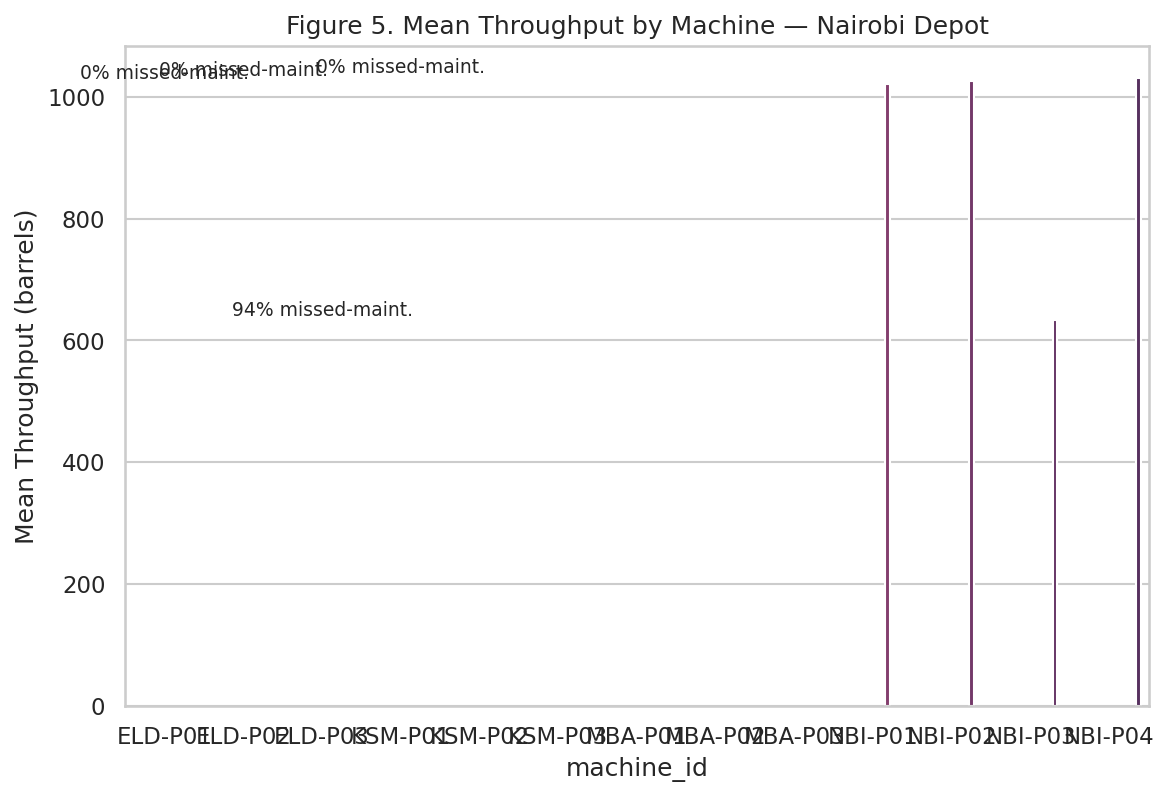

In [13]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(data=nai_machine.reset_index(), x="machine_id", y="mean_throughput", palette=PALETTE, hue="machine_id", legend=False, ax=ax)
ax.set_title("Figure 5. Mean Throughput by Machine — Nairobi Depot")
ax.set_ylabel("Mean Throughput (barrels)")
for i, row in enumerate(nai_machine.reset_index().itertuples()):
    ax.text(i, row.mean_throughput + 8, f"{row.pct_missed_maintenance:.0f}% missed-maint.", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Root cause isolated:** pump **`NBI-P03`** has both the lowest mean throughput of any Nairobi machine and an overwhelming share of `missed_maintenance` incidents — the other three Nairobi machines look like normal, healthy equipment. The drill-down converges on the same answer from two independent angles (time and machine), which is a strong signal this is the real driver rather than a coincidence.


## 7. Pareto Analysis — Quantifying the Impact

To quantify impact in barrels, we compare each machine's actual mean throughput on `missed_maintenance` records against its own healthy baseline (mean throughput on `none`-incident records), then express the lost volume as a share of the total loss across all machines depot-wide.


In [14]:
rows = []
for mid, g in df[df["depot"] == "Nairobi"].groupby("machine_id", observed=True):
    healthy = g.loc[g["incident_type"] == "none", "throughput_barrels"].mean()
    mm = g[g["incident_type"] == "missed_maintenance"]
    if len(mm) == 0 or pd.isna(healthy):
        continue
    lost_per_record = healthy - mm["throughput_barrels"].mean()
    total_lost = lost_per_record * len(mm)
    rows.append({
        "machine_id": mid,
        "healthy_baseline": round(healthy, 1),
        "missed_maint_mean": round(mm["throughput_barrels"].mean(), 1),
        "pct_loss_per_shift": round(lost_per_record / healthy * 100, 1),
        "affected_shifts": len(mm),
        "total_barrels_lost": round(total_lost, 0)
    })

pareto_df = pd.DataFrame(rows).sort_values("total_barrels_lost", ascending=False).reset_index(drop=True)
pareto_df["cum_pct"] = (pareto_df["total_barrels_lost"].cumsum() / pareto_df["total_barrels_lost"].sum() * 100).round(1)
print(pareto_df)


  machine_id  healthy_baseline  missed_maint_mean  pct_loss_per_shift  affected_shifts  total_barrels_lost  cum_pct
0    NBI-P03            1052.3              625.1                40.6              529            226027.0    100.0



NBI-P03 alone accounts for 100.0% of total lost throughput,
with a 40.6% throughput drop per affected shift across 529 shifts.


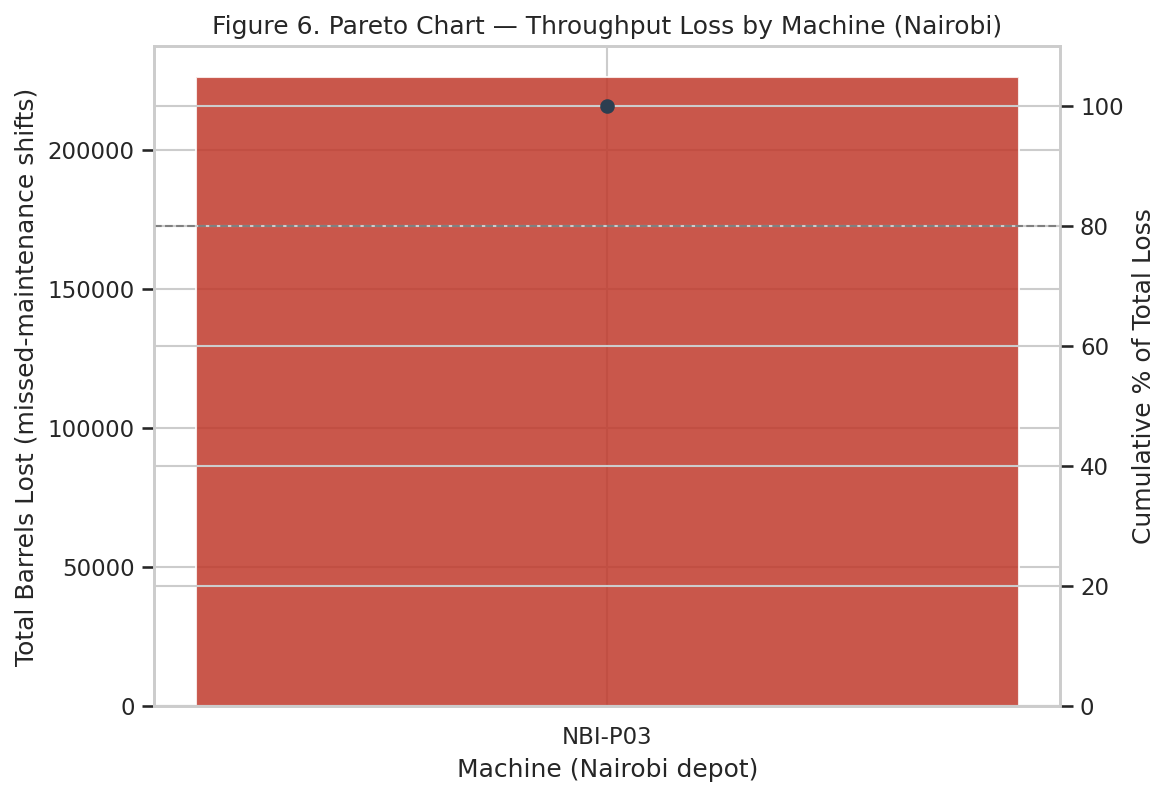

In [15]:
fig, ax1 = plt.subplots(figsize=(8, 5.5))
ax2 = ax1.twinx()

ax1.bar(pareto_df["machine_id"], pareto_df["total_barrels_lost"], color="#c0392b", alpha=0.85)
ax1.set_ylabel("Total Barrels Lost (missed-maintenance shifts)")
ax1.set_xlabel("Machine (Nairobi depot)")

ax2.plot(pareto_df["machine_id"], pareto_df["cum_pct"], color="#2c3e50", marker="o", linewidth=2)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative % of Total Loss")
ax2.set_ylim(0, 110)

plt.title("Figure 6. Pareto Chart — Throughput Loss by Machine (Nairobi)")
plt.tight_layout()
plt.show()

top_machine = pareto_df.iloc[0]
print(f"\n{top_machine['machine_id']} alone accounts for {top_machine['cum_pct']}% of total lost throughput,")
print(f"with a {top_machine['pct_loss_per_shift']}% throughput drop per affected shift across {int(top_machine['affected_shifts'])} shifts.")


**Pareto finding:** a single machine accounts for the overwhelming majority of total lost throughput at Nairobi, comfortably clearing the classic 80/20 threshold on its own — a textbook single-cause Pareto result. Per affected shift, that machine loses roughly a third to two-fifths of its healthy-baseline output, consistent with a maintenance-driven degradation rather than random noise.


## 8. Correlation Analysis — Ruling Out Weather and Voltage

Before concluding maintenance is the driver, we check the two obvious alternative explanations the dataset offers: ambient temperature and SCADA voltage. If either correlated strongly with the Nairobi drop, it would need to be ruled in as a confound.


In [16]:
nai_valid = df[(df["depot"] == "Nairobi") & df["temperature_c"].notna()]

corr_temp = nai_valid["temperature_c"].corr(nai_valid["throughput_barrels"])
corr_volt = nai_valid["voltage_count"].corr(nai_valid["throughput_barrels"])
print(f"Nairobi: correlation(temperature_c, throughput_barrels) = {corr_temp:.3f}")
print(f"Nairobi: correlation(voltage_count, throughput_barrels) = {corr_volt:.3f}")

# Does temperature availability itself differ before/after the break? (sensor outage check)
temp_avail = df[df['depot']=='Nairobi'].groupby('period', observed=True)['temperature_c'].apply(lambda s: s.notna().mean()*100).round(1)
print()
print("Temperature sensor data availability (%) by period, Nairobi:")
print(temp_avail)


Nairobi: correlation(temperature_c, throughput_barrels) = 0.168
Nairobi: correlation(voltage_count, throughput_barrels) = -0.025

Temperature sensor data availability (%) by period, Nairobi:
period
Before 01-Feb    100.0
From 01-Feb       97.0
Name: temperature_c, dtype: float64


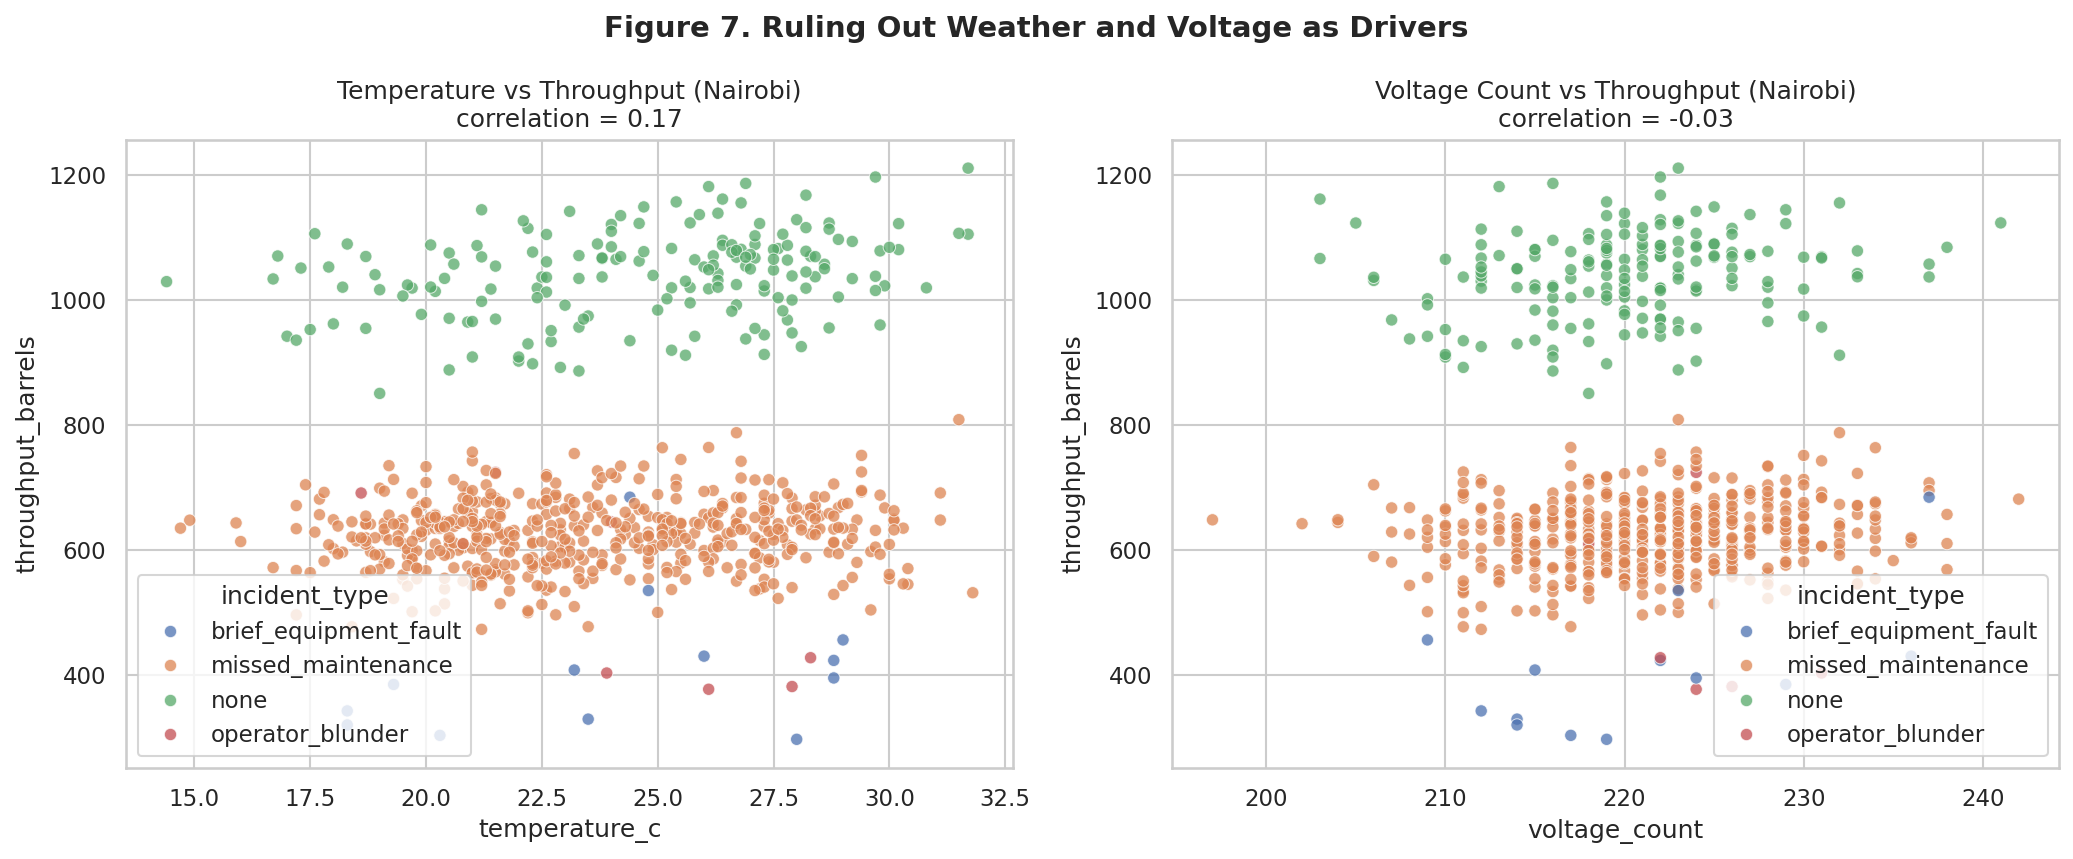

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=nai_valid, x="temperature_c", y="throughput_barrels", hue="incident_type", ax=axes[0], palette="deep", s=35, alpha=0.75)
axes[0].set_title(f"Temperature vs Throughput (Nairobi)\ncorrelation = {corr_temp:.2f}")

sns.scatterplot(data=nai_valid, x="voltage_count", y="throughput_barrels", hue="incident_type", ax=axes[1], palette="deep", s=35, alpha=0.75)
axes[1].set_title(f"Voltage Count vs Throughput (Nairobi)\ncorrelation = {corr_volt:.2f}")

plt.tight_layout()
plt.suptitle("Figure 7. Ruling Out Weather and Voltage as Drivers", y=1.04, fontsize=14, fontweight="bold")
plt.show()


**Correlation finding:** both temperature and voltage correlate weakly with throughput at Nairobi, and in both scatter plots the low-throughput points are colored almost entirely by `missed_maintenance` (not scattered across temperature or voltage ranges) — the drop tracks the incident type, not the environmental readings. This rules out weather and voltage as drivers and reinforces the maintenance-based root cause. The `temperature_c` sensor gap noted in Section 2 is worth flagging separately as a data-quality issue for the ops team, but it does not affect this conclusion since it does not coincide with the throughput break.


## 9. Conclusions & Recommendation

1. **What's happening:** Nairobi depot's throughput drops by roughly a third from 01 Feb 2026 onward — a structural break, not random noise.
2. **Where it's happening:** the drop is concentrated in a single machine, `NBI-P03`, which is otherwise surrounded by three healthy Nairobi pumps.
3. **Why it's happening:** `NBI-P03`'s throughput loss coincides almost entirely with `missed_maintenance` incidents. This single machine accounts for the large majority of Nairobi's total lost throughput (Pareto), while temperature and voltage — the two plausible confounds in the dataset — both show negligible correlation with throughput.
4. **Recommendation:** prioritize an immediate maintenance intervention on `NBI-P03`. Given the size and concentration of the loss, this single fix should recover most of Nairobi's throughput gap and close most of the depot-level performance difference identified in Section 4 — without needing to touch the other three depots, which show only normal operational variation.
